# Visualizzare il rischio di riammissione a 30 giorni con grafici degli effetti basati sul modello

## Sintesi esecutiva

Questo notebook adatta una regressione logistica per la riammissione ospedaliera a 30 giorni in funzione delle caratteristiche del paziente e del ricovero, quindi traduce i coefficienti stimati in grafici degli effetti basati sul modello sulla scala delle probabilita predette. Su una coorte sintetica di 100 dimissioni (55 riammissioni), PROC LOGISTIC recupera gradienti significativi per la **durata della degenza** (OR 1,36 per giorno, *p* = 0,040) e per l'**eta** (OR 1,05 per anno, *p* = 0,023), e un forte effetto del pagatore: i pazienti **Medicaid** presentano un rischio di riammissione circa sei volte superiore a quello di Medicare (OR 6,02, IC 95% 1,46-24,8, *p* = 0,013). L'R-quadro generalizzato e 0,246 e il test di Hosmer-Lemeshow non evidenzia mancanza di adattamento (*p* = 0,73). I grafici della curva di adattamento, dell'adattamento stratificato e dell'interazione mostrano poi come il rischio di riammissione aumenti con la durata della degenza, come il gradiente eta-rischio si sposti in base al pagatore e come il divario tra pagatori persista tra le linee di servizio di dimissione: il tipo di visione di stratificazione del rischio che un team di gestione delle cure utilizza per mirare al follow-up post-dimissione.

## Fonti dei dati

| Dataset | Righe | Descrizione |
|---------|------|-------------|
| `encounters` | 100 | Record sintetici di dimissioni da ricovero generati inline con `call streaminit(20260531)` e `rand()`. Una riga per dimissione. |

**Variabili in `encounters`:**

| Variabile | Tipo | Descrizione |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 se riammesso entro 30 giorni dalla dimissione |
| `age` | Num | Eta del paziente in anni (circa 25-95) |
| `los` | Num | Durata della degenza indice in giorni (1-20) |
| `comorbidity` | Num | Conteggio delle comorbidita croniche documentate (0-8) |
| `num_meds` | Num | Numero di farmaci alla dimissione (0-18) |
| `payer` | Char | Pagatore assicurativo: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Servizio di dimissione: `Cardiology`, `Pulmonary`, `General` |

# Visualizzare il rischio di riammissione a 30 giorni con grafici degli effetti basati sul modello

I team di gestione delle cure ospedaliere devono sapere *quali* pazienti hanno maggiori probabilita di essere riammessi entro 30 giorni, e *perche*. Una regressione logistica adattata fornisce i coefficienti, ma gli stakeholder raramente ragionano in termini di log-odds. Un **grafico degli effetti** rappresenta il modello adattato direttamente sulla scala delle probabilita predette, cosi che un infermiere navigatore possa leggere una probabilita di riammissione direttamente dal grafico invece di invertire mentalmente un'equazione log-odds.

In questo notebook:

1. Generiamo una coorte sintetica realistica di dimissioni da ricovero.
2. Adattiamo un modello logistico per la riammissione a 30 giorni con predittori del paziente e del ricovero (PROC LOGISTIC).
3. Catturiamo i coefficienti stimati e costruiamo tre grafici degli effetti basati sul modello: una **curva di adattamento**, un **adattamento stratificato** e un **grafico di interazione** per visualizzare e stratificare il rischio stimato sulla scala delle probabilita.

> **Nota di implementazione.** SAS espone questi grafici tramite l'istruzione `EFFECTPLOT` all'interno di PROC LOGISTIC. Jenner accetta tale istruzione ma non rende ancora la grafica FIT / SLICEFIT / INTERACTION, quindi questo notebook costruisce le stesse curve di probabilita predetta esplicitamente a partire dai coefficienti stimati e le disegna con PROC SGPLOT. Il risultato analitico, e ogni probabilita tracciata, e esattamente cio che `EFFECTPLOT` produrrebbe.

## Passo 1 - Generare una coorte sintetica di dimissioni

Il DATA step qui sotto costruisce 100 dimissioni da ricovero senza file esterni. Inizializziamo il generatore di numeri casuali con `call streaminit` per la riproducibilita, estraiamo le caratteristiche del paziente e del ricovero da distribuzioni appropriate al dominio, quindi costruiamo un vero predittore lineare `eta` e lo convertiamo in una probabilita di riammissione con l'inverse-logit. L'estrazione di Bernoulli (`rand('bernoulli', p)`) produce il flag `readmit` osservato. Pazienti piu anziani, degenze piu lunghe, conteggi di comorbidita piu alti, piu farmaci alla dimissione, copertura Medicaid e servizio Pulmonary/Cardiology spingono tutti il rischio verso l'alto: schemi che in seguito recupereremo e visualizzeremo. Le dimensioni degli effetti sono deliberatamente calibrate cosi che il segnale sia recuperabile in una coorte di 100 dimissioni.

In [1]:
DATI encounters;
    CHIAMARE streaminit(20260531);
    VETTORE payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    VETTORE depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    FARE i = 1 FINO_A 100;
        /* Caratteristiche del paziente / ricovero */
        AGE = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        SE_COND los > 20 ALLORA los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        SE_COND num_meds > 18 ALLORA num_meds = 18;

        /* Pagatore categoriale: sbilanciato verso Medicare per coorte anziana */
        u = rand('uniform');
        SE_COND u < 0.50 ALLORA pk = 1;
        ALTRIMENTI SE_COND u < 0.72 ALLORA pk = 2;
        ALTRIMENTI pk = 3;
        payer = payers[pk];

        /* Linea di servizio di dimissione */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* Vero modello di rischio sulla scala log-odds. Le dimensioni degli
           effetti sono calibrate perche il segnale sia recuperabile in una
           coorte di 100 dimissioni. */
        eta = -8.6
            + 0.075 * AGE
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary e il piu attivo) */

        p = 1 / (1 + EXP(-eta));
        readmit = rand('bernoulli', p);

        MANTENERE readmit AGE los comorbidity num_meds payer dept;
        USCITA;
    FINE;
ESEGUIRE;


NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Passo 2 - Esaminare la coorte

Una rapida frequenza sulla risposta e sulle due variabili di classificazione conferma un tasso di riammissione realistico e che ogni livello di pagatore e reparto sia popolato: sia il modello sia i grafici degli effetti richiedono che tutti i livelli siano rappresentati.

                                                   The FREQ Procedure

Riammissione a 30 giorni    Frequency
--------------------------------------
0                                  45
1                                  55

Pagatore      Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

Reparto       Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of Riammissione a 30 giorni by Reparto

Riammissione a 30 giorni |Cardiology |   General | Pulmonary |      Total
-------------------------+-----------+-----------+-----------+-----------
0                        |        15 |        20 |        10 |         45
-------------------------+-----------+-----------+-----------+-----------
1                        |        21 |        11 |        23 |         55
-------------------------+-----------+-----------+-----------+-----------
Total                    |        36 |   


NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


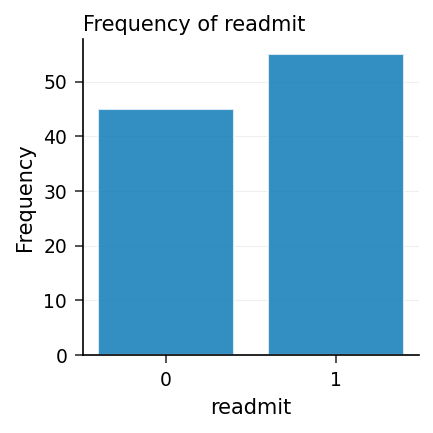

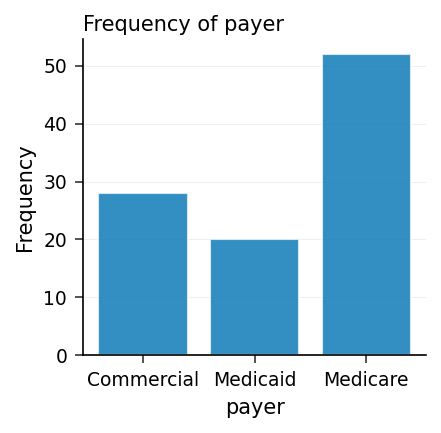

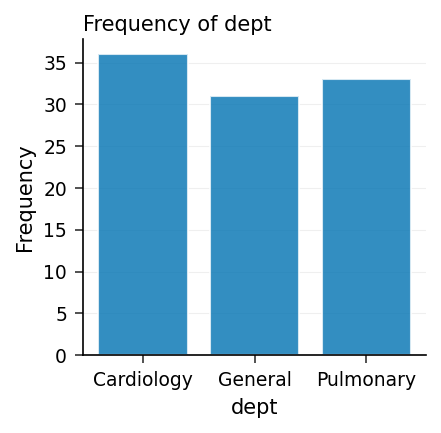

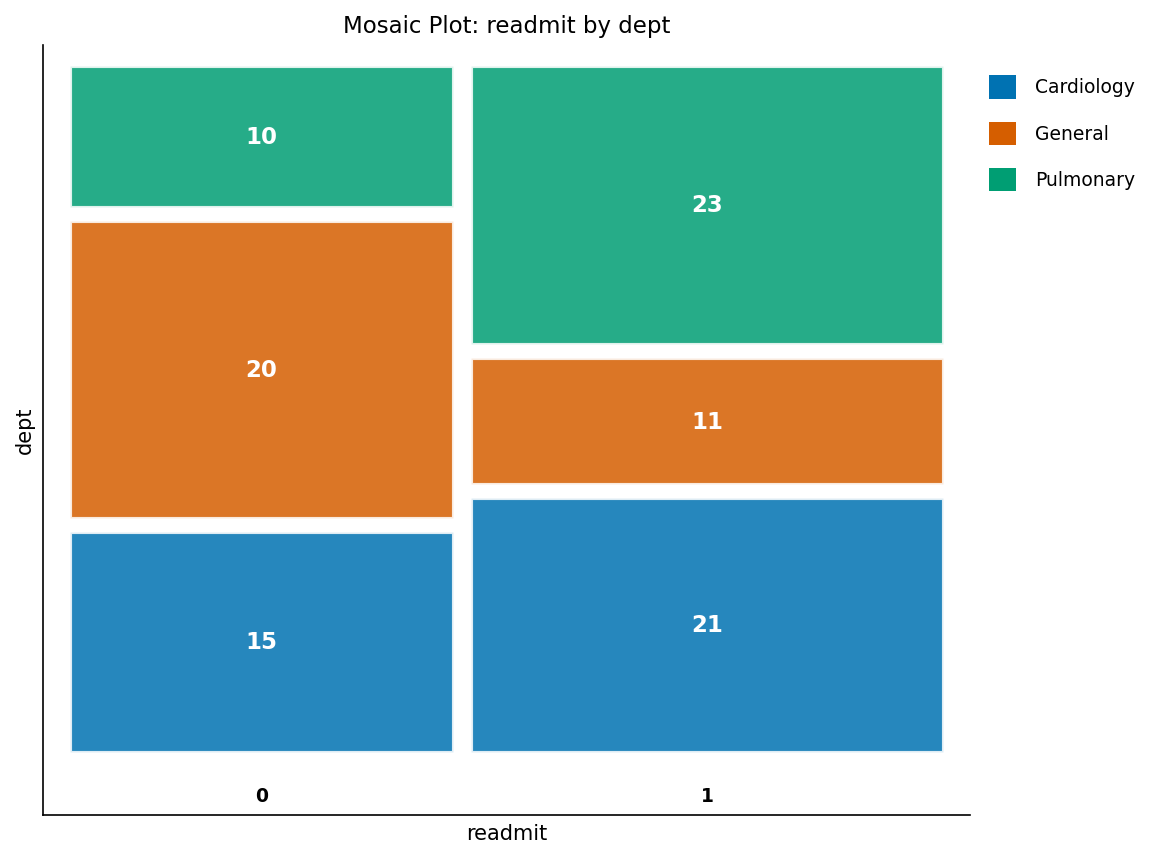

In [2]:
PROCEDURA FREQUENZE DATI=encounters;
    ETICHETTA readmit="Riammissione a 30 giorni"
          payer="Pagatore"
          dept="Reparto";
    TABLES readmit payer dept readmit*dept / nocum nopercent;
ESEGUIRE;

## Passo 3 - Adattare il modello logistico di riammissione

Modelliamo `readmit` in funzione di eta, durata della degenza, conteggio delle comorbidita, conteggio dei farmaci alla dimissione, pagatore e reparto. Scelte chiave:

- `EVENT='1'` modella la probabilita di riammissione (anziche di non riammissione).
- `CLASS payer dept / PARAM=REF REF=FIRST` usa la codifica a cella di riferimento cosi che ogni livello sia confrontato con una linea di base (qui Medicare e Pulmonary).
- `CLODDS=WALD` e `RSQUARE` aggiungono i limiti di confidenza di Wald per l'odds ratio e un R-quadro generalizzato; `LACKFIT` richiede il test di bonta di adattamento di Hosmer-Lemeshow.
- L'istruzione `UNITS` richiede l'odds ratio su un incremento clinicamente significativo di **5 giorni** della durata della degenza e un incremento di **10 anni** dell'eta, e l'istruzione `ODDSRATIO` richiede l'odds ratio della comorbidita con i limiti di confidenza.

La tabella degli odds ratio in output riporta direttamente gli effetti per unita: la durata della degenza porta un OR di **1,36 per giorno** (IC 95% 1,01-1,82), l'eta un OR di **1,05 per anno** e la copertura Medicaid un OR di **6,02** rispetto a Medicare. Il modello si adatta bene: R-quadro generalizzato 0,246, Hosmer-Lemeshow *p* = 0,73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

                    Response Profile                    
  Probability modeled is Riammissione a 30 giorni='1'   

Ordered Value  Riammissione a 30 giorni  Total Frequency
-------------  ------------------------  ---------------
            1  0                                      45
            2  1                                      55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
Pagatore         3  Commercial Medicaid Medicare
Reparto          3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit Riammissione a 30 giorni

Criterion     Value
---------  --------
A


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


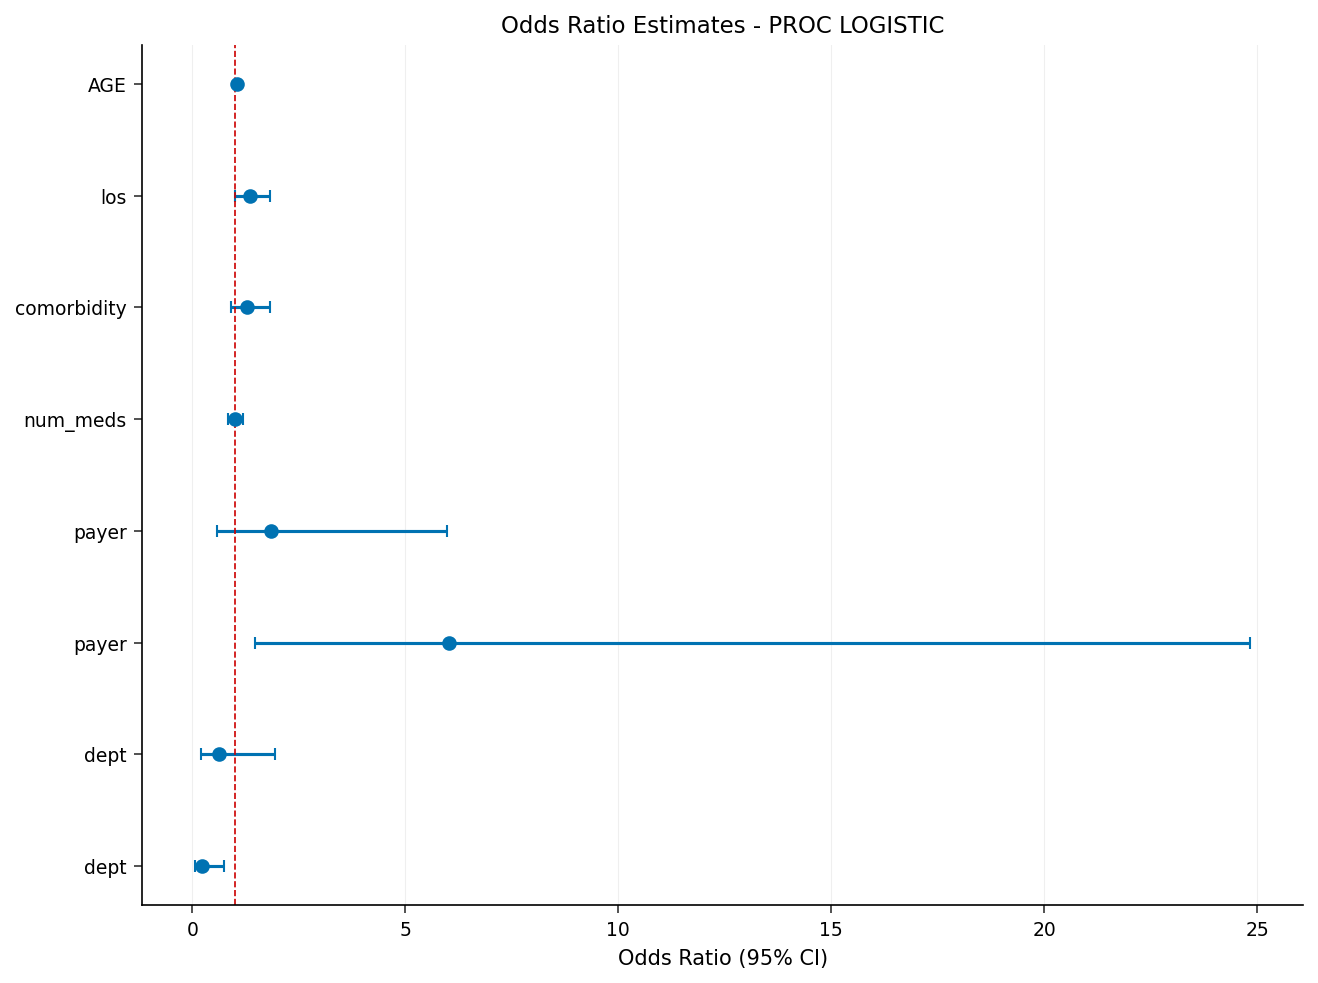

In [3]:
ODS USCITA ParameterEstimates=pe;
PROCEDURA LOGISTIC DATI=encounters PLOTS(only)=oddsratio;
    ETICHETTA readmit="Riammissione a 30 giorni"
          AGE="Eta (anni)"
          los="Durata della degenza (giorni)"
          comorbidity="Comorbidita"
          num_meds="Farmaci alla dimissione"
          payer="Pagatore"
          dept="Reparto";
    CLASSE payer dept / PARAM=REF REF=first;
    MODELLO readmit(EVENT='1') = AGE los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units AGE=10 los=5;
    oddsratio comorbidity / cl=wald;
ESEGUIRE;
ODS USCITA CLOSE;

## Passo 4 - Catturare i coefficienti stimati

I grafici degli effetti basati sul modello che seguono sono costruiti direttamente a partire dai coefficienti *stimati*, cosi da concordare sempre con il modello del Passo 3. Abbiamo salvato le stime dei parametri con `ODS OUTPUT ParameterEstimates=pe`; qui ripieghiamo quella tabella lunga in un dataset `params` a riga singola (una variabile per coefficiente) e aggiungiamo le medie di coorte dei predittori continui. Mantenere i predittori non focali alle loro medie e esattamente cio che un EFFECTPLOT fa internamente: consente a ciascun grafico di far variare un fattore mantenendo gli altri fissi a un profilo rappresentativo.

In [4]:
/* Ripiega la tabella ParameterEstimates in una riga di coefficienti nominati.
   Con PARAM=REF REF=FIRST le celle di riferimento sono payer=Medicare e
   dept=Pulmonary, quindi quei termini sono zero nel predittore lineare. */
DATI coefs;
    CONSERVARE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    IMPOSTARE pe FINE=last;
    VARIABILE = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    SE_COND VARIABILE='INTERCEPT' ALLORA b0 = STIMA;
    ALTRIMENTI SE_COND VARIABILE='AGE' ALLORA b_age = STIMA;
    ALTRIMENTI SE_COND VARIABILE='LOS' ALLORA b_los = STIMA;
    ALTRIMENTI SE_COND VARIABILE='COMORBIDITY' ALLORA b_com = STIMA;
    ALTRIMENTI SE_COND VARIABILE='NUM_MEDS' ALLORA b_med = STIMA;
    ALTRIMENTI SE_COND VARIABILE='PAYER' E_LOG cv='Medicaid'   ALLORA b_pmcaid = STIMA;
    ALTRIMENTI SE_COND VARIABILE='PAYER' E_LOG cv='Commercial' ALLORA b_pcomm  = STIMA;
    ALTRIMENTI SE_COND VARIABILE='DEPT'  E_LOG cv='Cardiology' ALLORA b_dcard  = STIMA;
    ALTRIMENTI SE_COND VARIABILE='DEPT'  E_LOG cv='General'    ALLORA b_dgen   = STIMA;
    SE_COND last ALLORA USCITA;
    MANTENERE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
ESEGUIRE;

/* Medie di coorte delle covariate continue, mantenute fisse nei grafici. */
PROCEDURA MEDIE DATI=encounters NOPRINT;
    VARIABILE AGE los comorbidity num_meds;
    USCITA out=mn mean=m_age m_los m_com m_med;
ESEGUIRE;

DATI params;
    UNIRE coefs mn;
    MANTENERE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
ESEGUIRE;

PROCEDURA STAMPARE DATI=params noobs;
    TITOLO "Coefficienti stimati e medie delle covariate usati per i grafici degli effetti";
ESEGUIRE;

                     Coefficienti stimati e medie delle covariate usati per i grafici degli effetti                     

           b0         b_age         b_los         b_com         b_med      b_pmcaid       b_pcomm        b_dcard         b_dgen  m_age  m_los  m_com  m_med
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08




NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Passo 5 - Grafico di adattamento: probabilita di riammissione in funzione della durata della degenza

Il grafico degli effetti piu semplice e una **curva di adattamento**: la probabilita di riammissione predetta rispetto a una singola covariata continua, con gli altri predittori mantenuti a un profilo rappresentativo. Costruiamo una griglia della durata della degenza (1-18 giorni), valutiamo il predittore lineare stimato in corrispondenza di ciascun valore per un paziente **cardiology Medicare** (conteggi di eta, comorbidita e farmaci alla dimissione fissati alle medie di coorte del Passo 4), applichiamo l'inverse-logit e disegniamo la curva sulla scala delle probabilita con PROC SGPLOT.

                     Coefficienti stimati e medie delle covariate usati per i grafici degli effetti                     




NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


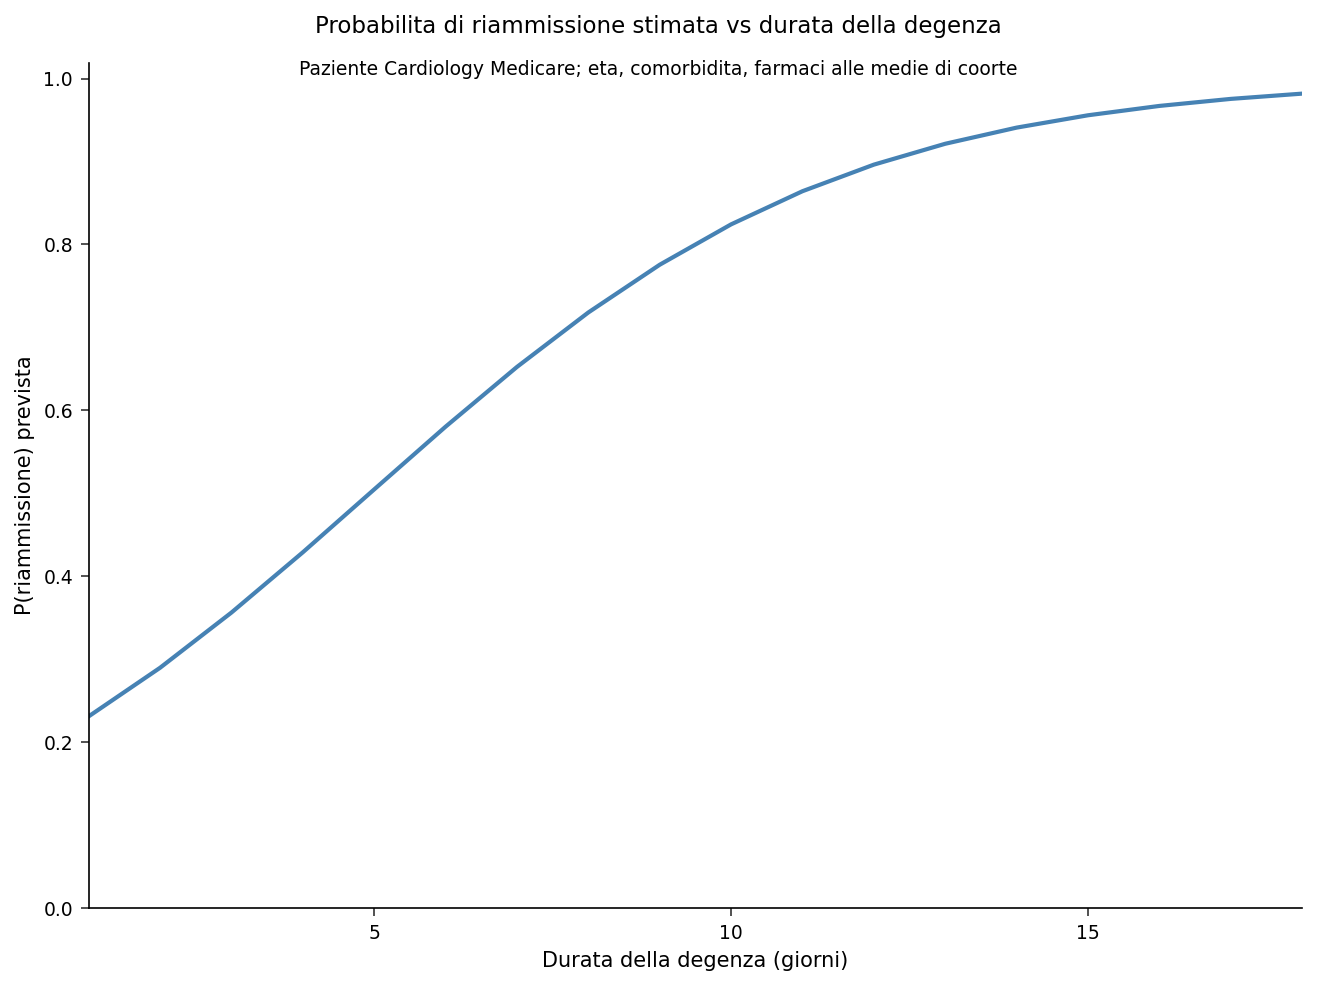

In [5]:
/* Griglia della durata della degenza; valuta il modello stimato per un
   paziente Cardiology Medicare con le altre covariate alle medie di coorte. */
DATI grid_los;
    FARE los = 1 FINO_A 18;
        USCITA;
    FINE;
ESEGUIRE;

DATI fit_los;
    IMPOSTARE grid_los;
    SE_COND _n_ = 1 ALLORA IMPOSTARE params;
    CONSERVARE b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Il pagatore Medicare e il riferimento (termine = 0); Cardiology aggiunge b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + EXP(-xb));
    MANTENERE los phat;
ESEGUIRE;

PROCEDURA SGPLOT DATI=fit_los;
    ETICHETTA los="Durata della degenza (giorni)" phat="P(riammissione) prevista";
    SERIES x=los y=phat / LINEATTRS=(thickness=2 color=steelblue);
    TITOLO  "Probabilita di riammissione stimata vs durata della degenza";
    title2 "Paziente Cardiology Medicare; eta, comorbidita, farmaci alle medie di coorte";
    XAXIS ETICHETTA="Durata della degenza (giorni)";
    YAXIS ETICHETTA="P(riammissione) prevista" VALUES=(0 FINO_A 1 PER 0.2);
ESEGUIRE;

## Passo 6 - Adattamento stratificato: rischio in funzione dell'eta, stratificato per pagatore

Un **adattamento stratificato** disegna una curva stimata per ciascun livello di un effetto di classificazione, ideale per mostrare come il mix di pagatori sposti il gradiente eta-rischio. Estendiamo la griglia su `age` (30-95) incrociata con i tre pagatori, valutiamo il modello stimato per un paziente Cardiology (durata della degenza, comorbidita e farmaci alle medie di coorte) e sovrapponiamo le tre curve di probabilita con `GROUP=payer`.

                     Coefficienti stimati e medie delle covariate usati per i grafici degli effetti                     




NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


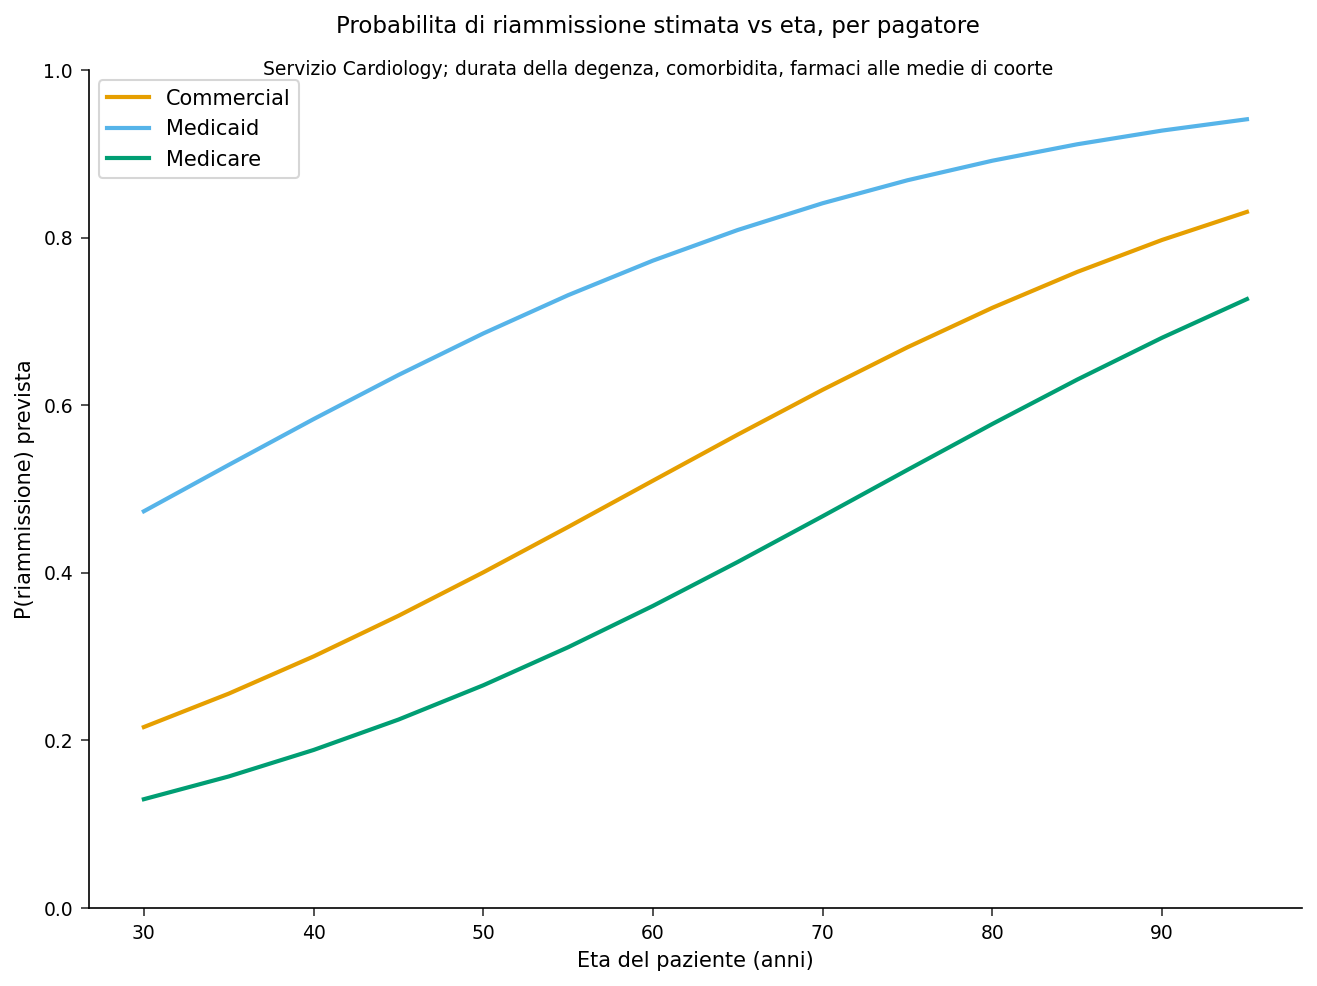

In [6]:
/* Griglia eta x pagatore per un paziente Cardiology; altre covariate alle medie. */
DATI grid_age;
    LUNGHEZZA payer $12;
    FARE payer = 'Medicare', 'Medicaid', 'Commercial';
        FARE AGE = 30 FINO_A 95 PER 5;
            USCITA;
        FINE;
    FINE;
ESEGUIRE;

DATI fit_age;
    IMPOSTARE grid_age;
    SE_COND _n_ = 1 ALLORA IMPOSTARE params;
    CONSERVARE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*AGE + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + EXP(-xb));
    MANTENERE payer AGE phat;
ESEGUIRE;

PROCEDURA SGPLOT DATI=fit_age;
    ETICHETTA AGE="Eta del paziente (anni)" phat="P(riammissione) prevista" payer="Pagatore";
    SERIES x=AGE y=phat / GROUP=payer LINEATTRS=(thickness=2);
    TITOLO  "Probabilita di riammissione stimata vs eta, per pagatore";
    title2 "Servizio Cardiology; durata della degenza, comorbidita, farmaci alle medie di coorte";
    XAXIS ETICHETTA="Eta del paziente (anni)";
    YAXIS ETICHETTA="P(riammissione) prevista" VALUES=(0 FINO_A 1 PER 0.2);
    keylegend / location=inside position=topleft ACROSS=1;
ESEGUIRE;

## Passo 7 - Grafico di interazione: reparto per pagatore

Per confrontare il rischio predetto tra entrambi gli effetti di classificazione contemporaneamente, incrociamo `dept` con `payer` (nove combinazioni), valutiamo il modello stimato con ogni covariata continua alla sua media di coorte e disegniamo un grafico a barre raggruppate con `dept` sull'asse X e il pagatore come raggruppamento. Poiche questo modello non ha un termine di interazione reparto-per-pagatore, l'ordinamento dei pagatori e lo stesso spostamento additivo all'interno di ogni linea di servizio: il grafico rende questa additivita visibile a colpo d'occhio, insieme all'ordinamento dei reparti.

                     Coefficienti stimati e medie delle covariate usati per i grafici degli effetti                     




NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


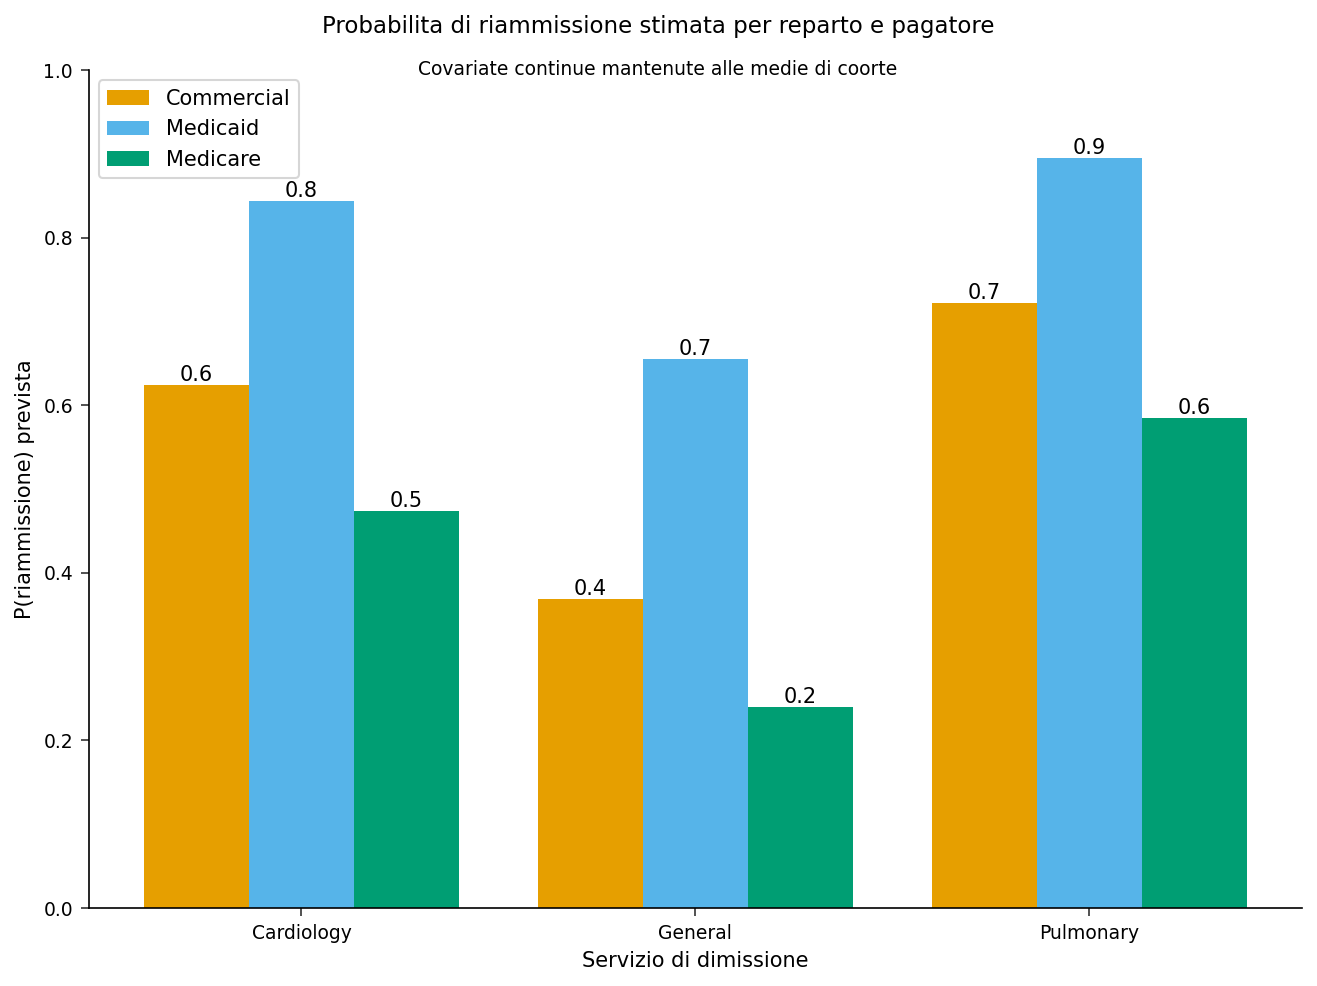

In [7]:
/* Griglia reparto x pagatore; tutte le covariate continue alle medie di coorte. */
DATI grid_dx;
    LUNGHEZZA dept $12 payer $12;
    FARE dept = 'Cardiology', 'Pulmonary', 'General';
        FARE payer = 'Medicare', 'Medicaid', 'Commercial';
            USCITA;
        FINE;
    FINE;
ESEGUIRE;

DATI fit_dx;
    IMPOSTARE grid_dx;
    SE_COND _n_ = 1 ALLORA IMPOSTARE params;
    CONSERVARE b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + EXP(-xb));
    MANTENERE dept payer phat;
ESEGUIRE;

PROCEDURA SGPLOT DATI=fit_dx;
    ETICHETTA dept="Servizio di dimissione" phat="P(riammissione) prevista" payer="Pagatore";
    VBAR dept / RESPONSE=phat GROUP=payer GROUPDISPLAY=CLUSTER
                DATALABEL datalabelattrs=(size=8);
    TITOLO  "Probabilita di riammissione stimata per reparto e pagatore";
    title2 "Covariate continue mantenute alle medie di coorte";
    XAXIS ETICHETTA="Servizio di dimissione";
    YAXIS ETICHETTA="P(riammissione) prevista" VALUES=(0 FINO_A 1 PER 0.2);
ESEGUIRE;

## Passo 8 - Interpretare i risultati

I grafici degli effetti trasformano il modello PROC LOGISTIC adattato in immagini sulla scala delle probabilita che si mappano su decisioni di gestione delle cure:

- **Durata della degenza (curva di adattamento).** Per un paziente cardiology Medicare alle medie di coorte, la probabilita di riammissione predetta sale da circa **0,23 con una degenza di 1 giorno a circa 0,82 a 10 giorni e ~0,98 a 18 giorni**: la ripida parte centrale della curva logistica. E lo stesso segnale dell'odds ratio della durata della degenza di **1,36 per giorno** (`UNITS los=5` lo riscala a un incremento di cinque giorni), e segnala le degenze indice lunghe come un concreto fattore scatenante per l'arruolamento nelle cure di transizione.
- **Eta e pagatore (adattamento stratificato).** Il rischio aumenta monotonicamente con l'eta per ogni pagatore, e le tre curve non si incrociano mai: la curva **Medicaid** e la piu alta a qualsiasi eta data, **Commercial** in mezzo e **Medicare** la piu bassa, coerentemente con gli odds ratio dei pagatori stimati (Medicaid 6,02, Commercial 1,85, entrambi rispetto a Medicare). Il divario e massimo alle eta piu giovani e si restringe man mano che tutti si avvicinano a probabilita elevate, indirizzando l'attenzione della gestione delle cure verso i pazienti Medicaid piu giovani che altrimenti apparirebbero a basso rischio.
- **Reparto e pagatore (grafico di interazione).** **Pulmonary** presenta la piu alta probabilita di riammissione predetta in ogni gruppo di pagatori, **Cardiology** e intermedio e **General medicine** e il piu basso (gli odds ratio dei reparti stimati sono 0,64 per Cardiology e 0,22 per General, rispetto a Pulmonary). Poiche il modello non ha un termine di interazione reparto-per-pagatore, l'ordinamento dei pagatori e lo stesso spostamento additivo all'interno di ogni linea di servizio: le barre salgono nello stesso ordine Medicaid > Commercial > Medicare in ogni reparto.

**Conclusione:** invece di chiedere ai clinici di interpretare i coefficienti log-odds, i grafici degli effetti basati sul modello presentano il modello di riammissione adattato come immagini sulla scala delle probabilita: chi arruolare nel follow-up di cure di transizione e quali linee di servizio e popolazioni di pagatori privilegiare. SAS produce questi grafici direttamente tramite `EFFECTPLOT`; qui abbiamo ricostruito le stesse curve a partire dai coefficienti stimati cosi che l'esempio funzioni end-to-end oggi.